# New must glycerol estimability and optimal experimental design

This notebook documents the calibration-prior, estimability, and model-based design workflow for the new natural and synthetic must datasets. CO2 and aroma states are intentionally excluded in this iteration; dead biomass and glycerol are included.

## Model extension

The state vector is

$$z(t)=\left[X, X_d, N, G, F, E, Gly\right]^T.$$ 

The base kinetic equations retain the effective Zenteno formulation used in the previous notebook. Dead biomass is represented as

$$\frac{dX_d}{dt}=K_d(T,E)X,$$

and viable biomass as

$$\frac{dX}{dt}=\left(\mu-K_d\right)X + u_X(t).$$

Glycerol is added as a fermentation-associated by-product:

$$\frac{dGly}{dt}=\left(\gamma_{G,0}\,\phi_G(T,G,E)+\gamma_{F,0}\,\phi_F(T,F,G,E)\right)X.$$

The factors $\phi_G$ and $\phi_F$ are the same effective fermentation factors that multiply the ethanol rates. This makes glycerol informative for the same sugar/ethanol-inhibition subspace, rather than treating it as an independent empirical curve.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT / 'fermentation_model').exists():
    ROOT = ROOT / 'fermentation_model'
RESULTS = ROOT / 'results/new_must_glycerol_estimability_doe'
fit_summary = pd.read_csv(RESULTS / 'fit_summary.csv')
param_summary = pd.read_csv(RESULTS / 'parameter_estimability_summary.csv')
candidate_ranking = pd.read_csv(RESULTS / 'candidate_ranking.csv')
selected_hybrid = pd.read_csv(RESULTS / 'selected_campaign_hybrid.csv')
selected_dopt = pd.read_csv(RESULTS / 'selected_campaign_d_opt.csv')
fit_summary

,fit,n_batches,mediums,parameters,n_parameters,success,status,message,nfev,initial_wsse,final_wsse,n_residuals,dof,wsse_per_residual,wsse_per_dof,l2_lambda,l2_parameters
0,natural_reduced11,9,natural,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,12,54080.575823,13409.522295,608,597,22.055135,22.461511,0.0,NaN
1,synthetic_reduced11,10,synthetic,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,16,54936.855968,10723.794146,542,531,19.785598,20.195469,0.0,NaN
2,mixed_reduced11,19,"natural,synthetic","mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,16,109017.431791,27138.922255,1150,1139,23.599063,23.826973,0.0,NaN
3,mixed_full17_l2,19,"natural,synthetic","mu0,sN,qN,qXG,qXF,betaG0,sG,betaF0,sF,qEG,qEF,...",17,True,3,`xtol` termination condition is satisfied.,9,27167.566680,26132.262359,1160,1143,22.527812,22.862872,1.0,"sN,qXG,qXF,sG,sF,iE,Kd0,m0,gammaG0,gammaF0"


## Calibration prior

Three calibration views are fitted: natural-only, synthetic-only, and mixed. The practical prior used for DOE is the mixed full-parameter L2 fit, because it preserves the complete parameter covariance while avoiding uncontrolled drift of weak directions.

In [2]:
display(fit_summary.sort_values('final_wsse'))
display(param_summary.sort_values(['analysis', 'std_log_approx']).head(30))

,fit,n_batches,mediums,parameters,n_parameters,success,status,message,nfev,initial_wsse,final_wsse,n_residuals,dof,wsse_per_residual,wsse_per_dof,l2_lambda,l2_parameters
1,synthetic_reduced11,10,synthetic,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,16,54936.855968,10723.794146,542,531,19.785598,20.195469,0.0,NaN
0,natural_reduced11,9,natural,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,12,54080.575823,13409.522295,608,597,22.055135,22.461511,0.0,NaN
3,mixed_full17_l2,19,"natural,synthetic","mu0,sN,qN,qXG,qXF,betaG0,sG,betaF0,sF,qEG,qEF,...",17,True,3,`xtol` termination condition is satisfied.,9,27167.566680,26132.262359,1160,1143,22.527812,22.862872,1.0,"sN,qXG,qXF,sG,sF,iE,Kd0,m0,gammaG0,gammaF0"
2,mixed_reduced11,19,"natural,synthetic","mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",11,True,3,`xtol` termination condition is satisfied.,16,109017.431791,27138.922255,1150,1139,23.599063,23.826973,0.0,NaN


,analysis,parameter,theta,std_log_approx,approx_95_multiplier,fim_diag,active_bound,classification
51,mixed_current_full_l2,mu0,0.061443,0.017008,1.033898,68030.920878,False,well_estimated
53,mixed_current_full_l2,qN,0.014078,0.017273,1.034435,39646.379732,False,well_estimated
60,mixed_current_full_l2,qEG,0.998681,0.030533,1.061672,54755.432118,False,well_estimated
66,mixed_current_full_l2,gammaG0,0.058460,0.039035,1.079511,21052.832468,False,well_estimated
64,mixed_current_full_l2,Kd0,0.000773,0.041284,1.084280,785.489107,False,well_estimated
56,mixed_current_full_l2,betaG0,0.429577,0.043180,1.088317,22136.771279,False,well_estimated
61,mixed_current_full_l2,qEF,0.600556,0.081265,1.172664,46782.139089,False,well_estimated
58,mixed_current_full_l2,betaF0,0.286346,0.087654,1.187444,16120.036343,False,well_estimated
57,mixed_current_full_l2,sG,0.038237,0.113229,1.248483,847.263494,False,well_estimated
63,mixed_current_full_l2,iE,0.005363,0.120901,1.267399,2722.595572,False,well_estimated


## Medium comparison

A parameter is considered reliable only if it is locally informed by the FIM and does not sit on an active bound. Medium-specific differences should be interpreted as structural/matrix-transfer evidence, not only as noise: natural and synthetic musts occupy different sugar and matrix regimes.

In [3]:
pivot = param_summary.pivot_table(index='parameter', columns='analysis', values='std_log_approx', aggfunc='first')
pivot.sort_index()

analysis,mixed_current_full_l2,mixed_current_reducedprior,natural_current,synthetic_current
parameter,,,,
Kd0,0.041284,0.044230,0.084546,0.038654
betaF0,0.087654,0.110199,0.180151,0.215029
betaG0,0.043180,0.050172,0.128106,0.083210
gammaF0,0.571337,14.749456,1.379745,21.297199
gammaG0,0.039035,0.042951,0.084529,0.059508
iE,0.120901,0.109221,0.250945,0.106007
iG,0.225759,0.267754,0.336524,0.504967
m0,6.253457,2.666144,5.191099,3.922799
mu0,0.017008,0.022314,0.045800,0.061052


## Profile likelihood

The profile likelihood check refits nuisance parameters while fixing selected parameters over a bounded local grid. A parameter is practically identifiable at 95% confidence when the likelihood-ratio curve crosses the $\chi^2_1(0.95)$ threshold on both sides of the estimate.

In [4]:
profile_path = RESULTS / 'profile_summary_combined.csv'
if not profile_path.exists():
    profile_path = RESULTS / 'profile_summary.csv'
pd.read_csv(profile_path) if profile_path.exists() else 'profile summary not available'

,parameter,n_success,max_lr_stat,crosses_left_95,crosses_right_95,profile_identifiable_95,chi2_95_threshold,profile_set
0,betaF0,6,1062.630731,True,True,True,3.841459,core
1,betaG0,6,407.686505,True,False,False,3.841459,core
2,iE,6,423.221139,True,True,True,3.841459,core
3,iG,6,193.239812,True,True,True,3.841459,core
4,mu0,6,3051.080748,True,True,True,3.841459,core
5,qEF,6,5272.555633,True,True,True,3.841459,core
6,qEG,6,6923.707778,True,True,True,3.841459,core
7,qN,6,5911.774168,True,True,True,3.841459,core
8,Kd0,6,374.761029,True,True,True,3.841459,weak
9,gammaF0,6,18.082379,True,True,True,3.841459,weak


## Model-based design of experiments

Candidate experiments are evaluated by their expected Fisher information matrix. The current-data FIM is used as prior information, and each new candidate contributes an additive FIM under the local linear approximation.

The main objective used for the proposed campaign is a hybrid deterministic score:

$$\Psi = \log\det(F) + 2\log\left(\frac{\lambda_{min}(F)}{\lambda_{max}(F)}\right) - 0.1\log\operatorname{tr}(F^{-1}).$$

This keeps D-optimality as the main information-volume criterion while penalizing designs that leave a very weak eigen-direction. A pure D-optimal benchmark is also reported.

In [5]:
display(candidate_ranking.head(12))
display(selected_hybrid)
display(selected_dopt)

,candidate,family,medium,horizon_h,status,error,new_logdet,new_min_eigenvalue,new_max_eigenvalue,new_min_relative_eigenvalue,...,var_ratio_Kd0,var_reduction_Kd0,var_ratio_m0,var_reduction_m0,var_ratio_gammaG0,var_reduction_gammaG0,var_ratio_gammaF0,var_reduction_gammaF0,weak_mean_var_reduction,weak_worst_var_reduction
0,synthetic_fructose_rich_glucose_pulse,sugar_separation,synthetic,216.0,ok,NaN,38.354230,8.853543e-05,17888.674221,4.949245e-09,...,0.912025,0.087975,0.710735,0.289265,0.616656,0.383344,0.444688,0.555312,0.320321,0.080852
1,synthetic_glucose_rich_fructose_pulse,sugar_separation,synthetic,216.0,ok,NaN,40.651731,4.129356e-04,13776.552580,2.997379e-08,...,0.774734,0.225266,0.396282,0.603718,0.663508,0.336492,0.670978,0.329022,0.312653,0.066295
2,synthetic_high_biomass_low_N_maintenance,maintenance,synthetic,216.0,ok,NaN,27.215191,3.739902e-04,13294.334606,2.813155e-08,...,0.732727,0.267273,0.588905,0.411095,0.852934,0.147066,0.812966,0.187034,0.245885,0.024182
3,synthetic_late_ethanol_death_probe,death,synthetic,216.0,ok,NaN,38.630846,1.892911e-04,7684.483014,2.463290e-08,...,0.684616,0.315384,0.898969,0.101031,0.932984,0.067016,0.943893,0.056107,0.173266,0.056107
4,synthetic_viable_biomass_step,biomass_input,synthetic,216.0,ok,NaN,36.067954,8.629017e-05,13196.200373,6.539016e-09,...,0.802237,0.197763,0.879803,0.120197,0.896727,0.103273,0.875832,0.124168,0.124881,0.026749
5,synthetic_ethanol_inhibition_challenge,ethanol_inhibition,synthetic,216.0,ok,NaN,30.552667,9.921065e-06,8430.172136,1.176852e-09,...,0.662203,0.337797,0.895268,0.104732,0.933549,0.066451,0.944582,0.055418,0.125932,0.006355
6,synthetic_high_sugar_reference,synthetic_baseline,synthetic,216.0,ok,NaN,34.242755,6.397477e-06,16366.498594,3.908885e-10,...,0.891509,0.108491,0.950013,0.049987,0.871535,0.128465,0.910257,0.089743,0.087783,0.014500
7,natural_glucose_pulse_after_growth,natural_sugar_pulse,natural,216.0,ok,NaN,29.767742,4.130343e-05,10771.490072,3.834514e-09,...,0.912443,0.087557,0.741871,0.258129,0.925499,0.074501,0.921373,0.078627,0.128471,0.022774
8,synthetic_low_yan_ladder,nitrogen_saturation,synthetic,216.0,ok,NaN,20.102818,4.632397e-06,6377.641875,7.263496e-10,...,0.973958,0.026042,0.914017,0.085983,0.921015,0.078985,0.956102,0.043898,0.126468,0.026042
9,natural_cold_hot_switch,natural_temperature,natural,216.0,ok,NaN,9.159697,8.249999e-19,6475.607776,1.274012e-22,...,0.974132,0.025868,0.944357,0.055643,0.913813,0.086187,0.896334,0.103666,0.078742,0.025868


,objective,campaign_order,candidate,family,medium,horizon_h,temperature_segments,score,rationale,campaign_logdet,...,var_ratio_Kd0,var_reduction_Kd0,var_ratio_m0,var_reduction_m0,var_ratio_gammaG0,var_reduction_gammaG0,var_ratio_gammaF0,var_reduction_gammaF0,weak_mean_var_reduction,weak_worst_var_reduction
0,hybrid,1,synthetic_glucose_rich_fructose_pulse,sugar_separation,synthetic,216.0,"17, 20, 23, 20",66.685991,High glucose plus fructose pulse separates glu...,96.205322,...,0.774734,0.225266,0.396282,0.603718,0.663508,0.336492,0.670978,0.329022,0.312653,0.066295
1,hybrid,2,synthetic_fructose_rich_glucose_pulse,sugar_separation,synthetic,216.0,"17, 20, 23, 20",70.340488,Fructose-rich run probes iG and fructose kinet...,99.972080,...,0.730631,0.269369,0.379802,0.620198,0.459317,0.540683,0.366987,0.633013,0.461598,0.143794
2,hybrid,3,synthetic_high_biomass_low_N_maintenance,maintenance,synthetic,216.0,"16, 18, 20, 18",73.004882,High biomass with low N creates low-growth sug...,102.173478,...,0.581502,0.418498,0.296594,0.703406,0.427572,0.572428,0.333223,0.666777,0.549665,0.160757
3,hybrid,4,synthetic_late_ethanol_death_probe,death,synthetic,216.0,"20, 25, 25, 22",74.535423,Late ethanol stress plus Xd observation target...,103.700638,...,0.456839,0.543161,0.283910,0.716090,0.414091,0.585909,0.324986,0.675014,0.612382,0.400003
4,hybrid,5,synthetic_viable_biomass_step,biomass_input,synthetic,216.0,"18, 22, 22, 18",75.594044,Known viable biomass addition tests rate propo...,104.688082,...,0.413523,0.586477,0.263304,0.736696,0.398273,0.601727,0.308280,0.691720,0.633988,0.416001
5,hybrid,6,synthetic_ethanol_inhibition_challenge,ethanol_inhibition,synthetic,216.0,"18, 22, 25, 22",76.523861,Initial ethanol decouples ethanol inhibition f...,105.626483,...,0.338750,0.661250,0.253326,0.746674,0.386095,0.613905,0.301977,0.698023,0.655239,0.418289
6,hybrid,7,synthetic_high_sugar_reference,synthetic_baseline,synthetic,216.0,"18, 20, 20, 18",77.392595,Synthetic high-sugar operating point close to ...,106.579302,...,0.324965,0.675035,0.244118,0.755882,0.358883,0.641117,0.291175,0.708825,0.669314,0.424793
7,hybrid,8,synthetic_low_yan_ladder,nitrogen_saturation,synthetic,216.0,"15, 18, 22, 22",78.176614,Low-YAN ladder targets sN and qN separation.,107.363145,...,0.322036,0.677964,0.237378,0.762622,0.343700,0.656300,0.286529,0.713471,0.693156,0.568027
8,hybrid,9,natural_glucose_pulse_after_growth,natural_sugar_pulse,natural,216.0,"18, 20, 22, 19",78.804569,Natural must with glucose perturbation to test...,107.999260,...,0.312861,0.687139,0.228325,0.771675,0.333398,0.666602,0.281702,0.718298,0.702338,0.573238


,objective,campaign_order,candidate,family,medium,horizon_h,temperature_segments,score,rationale,campaign_logdet,...,var_ratio_Kd0,var_reduction_Kd0,var_ratio_m0,var_reduction_m0,var_ratio_gammaG0,var_reduction_gammaG0,var_ratio_gammaF0,var_reduction_gammaF0,weak_mean_var_reduction,weak_worst_var_reduction
0,d_opt,1,synthetic_fructose_rich_glucose_pulse,sugar_separation,synthetic,216.0,"17, 20, 23, 20",96.593314,Fructose-rich run probes iG and fructose kinet...,96.593314,...,0.912025,0.087975,0.710735,0.289265,0.616656,0.383344,0.444688,0.555312,0.320321,0.080852
1,d_opt,2,synthetic_glucose_rich_fructose_pulse,sugar_separation,synthetic,216.0,"17, 20, 23, 20",99.972080,High glucose plus fructose pulse separates glu...,99.972080,...,0.730631,0.269369,0.379802,0.620198,0.459317,0.540683,0.366987,0.633013,0.461598,0.143794
2,d_opt,3,synthetic_high_biomass_low_N_maintenance,maintenance,synthetic,216.0,"16, 18, 20, 18",102.173478,High biomass with low N creates low-growth sug...,102.173478,...,0.581502,0.418498,0.296594,0.703406,0.427572,0.572428,0.333223,0.666777,0.549665,0.160757
3,d_opt,4,synthetic_late_ethanol_death_probe,death,synthetic,216.0,"20, 25, 25, 22",103.700638,Late ethanol stress plus Xd observation target...,103.700638,...,0.456839,0.543161,0.283910,0.716090,0.414091,0.585909,0.324986,0.675014,0.612382,0.400003
4,d_opt,5,synthetic_high_sugar_reference,synthetic_baseline,synthetic,216.0,"18, 20, 20, 18",104.747473,Synthetic high-sugar operating point close to ...,104.747473,...,0.432473,0.567527,0.273297,0.726703,0.383673,0.616327,0.313092,0.686908,0.629860,0.407828
5,d_opt,6,synthetic_ethanol_inhibition_challenge,ethanol_inhibition,synthetic,216.0,"18, 22, 25, 22",105.698592,Initial ethanol decouples ethanol inhibition f...,105.698592,...,0.351356,0.648644,0.261239,0.738761,0.371899,0.628101,0.306273,0.693727,0.652097,0.410096
6,d_opt,7,synthetic_viable_biomass_step,biomass_input,synthetic,216.0,"18, 22, 22, 18",106.579302,Known viable biomass addition tests rate propo...,106.579302,...,0.324965,0.675035,0.244118,0.755882,0.358883,0.641117,0.291175,0.708825,0.669314,0.424793
7,d_opt,8,synthetic_low_yan_ladder,nitrogen_saturation,synthetic,216.0,"15, 18, 22, 22",107.363145,Low-YAN ladder targets sN and qN separation.,107.363145,...,0.322036,0.677964,0.237378,0.762622,0.343700,0.656300,0.286529,0.713471,0.693156,0.568027
8,d_opt,9,natural_glucose_pulse_after_growth,natural_sugar_pulse,natural,216.0,"18, 20, 22, 19",107.999260,Natural must with glucose perturbation to test...,107.999260,...,0.312861,0.687139,0.228325,0.771675,0.333398,0.666602,0.281702,0.718298,0.702338,0.573238


## Input plots

The generated PNG files in `results/new_must_glycerol_estimability_doe/plots` show temperature setpoints, initial states, pulse timings, and feasible sampling windows for each selected candidate.

campaign_inputs_natural_glucose_pulse_after_growth.png


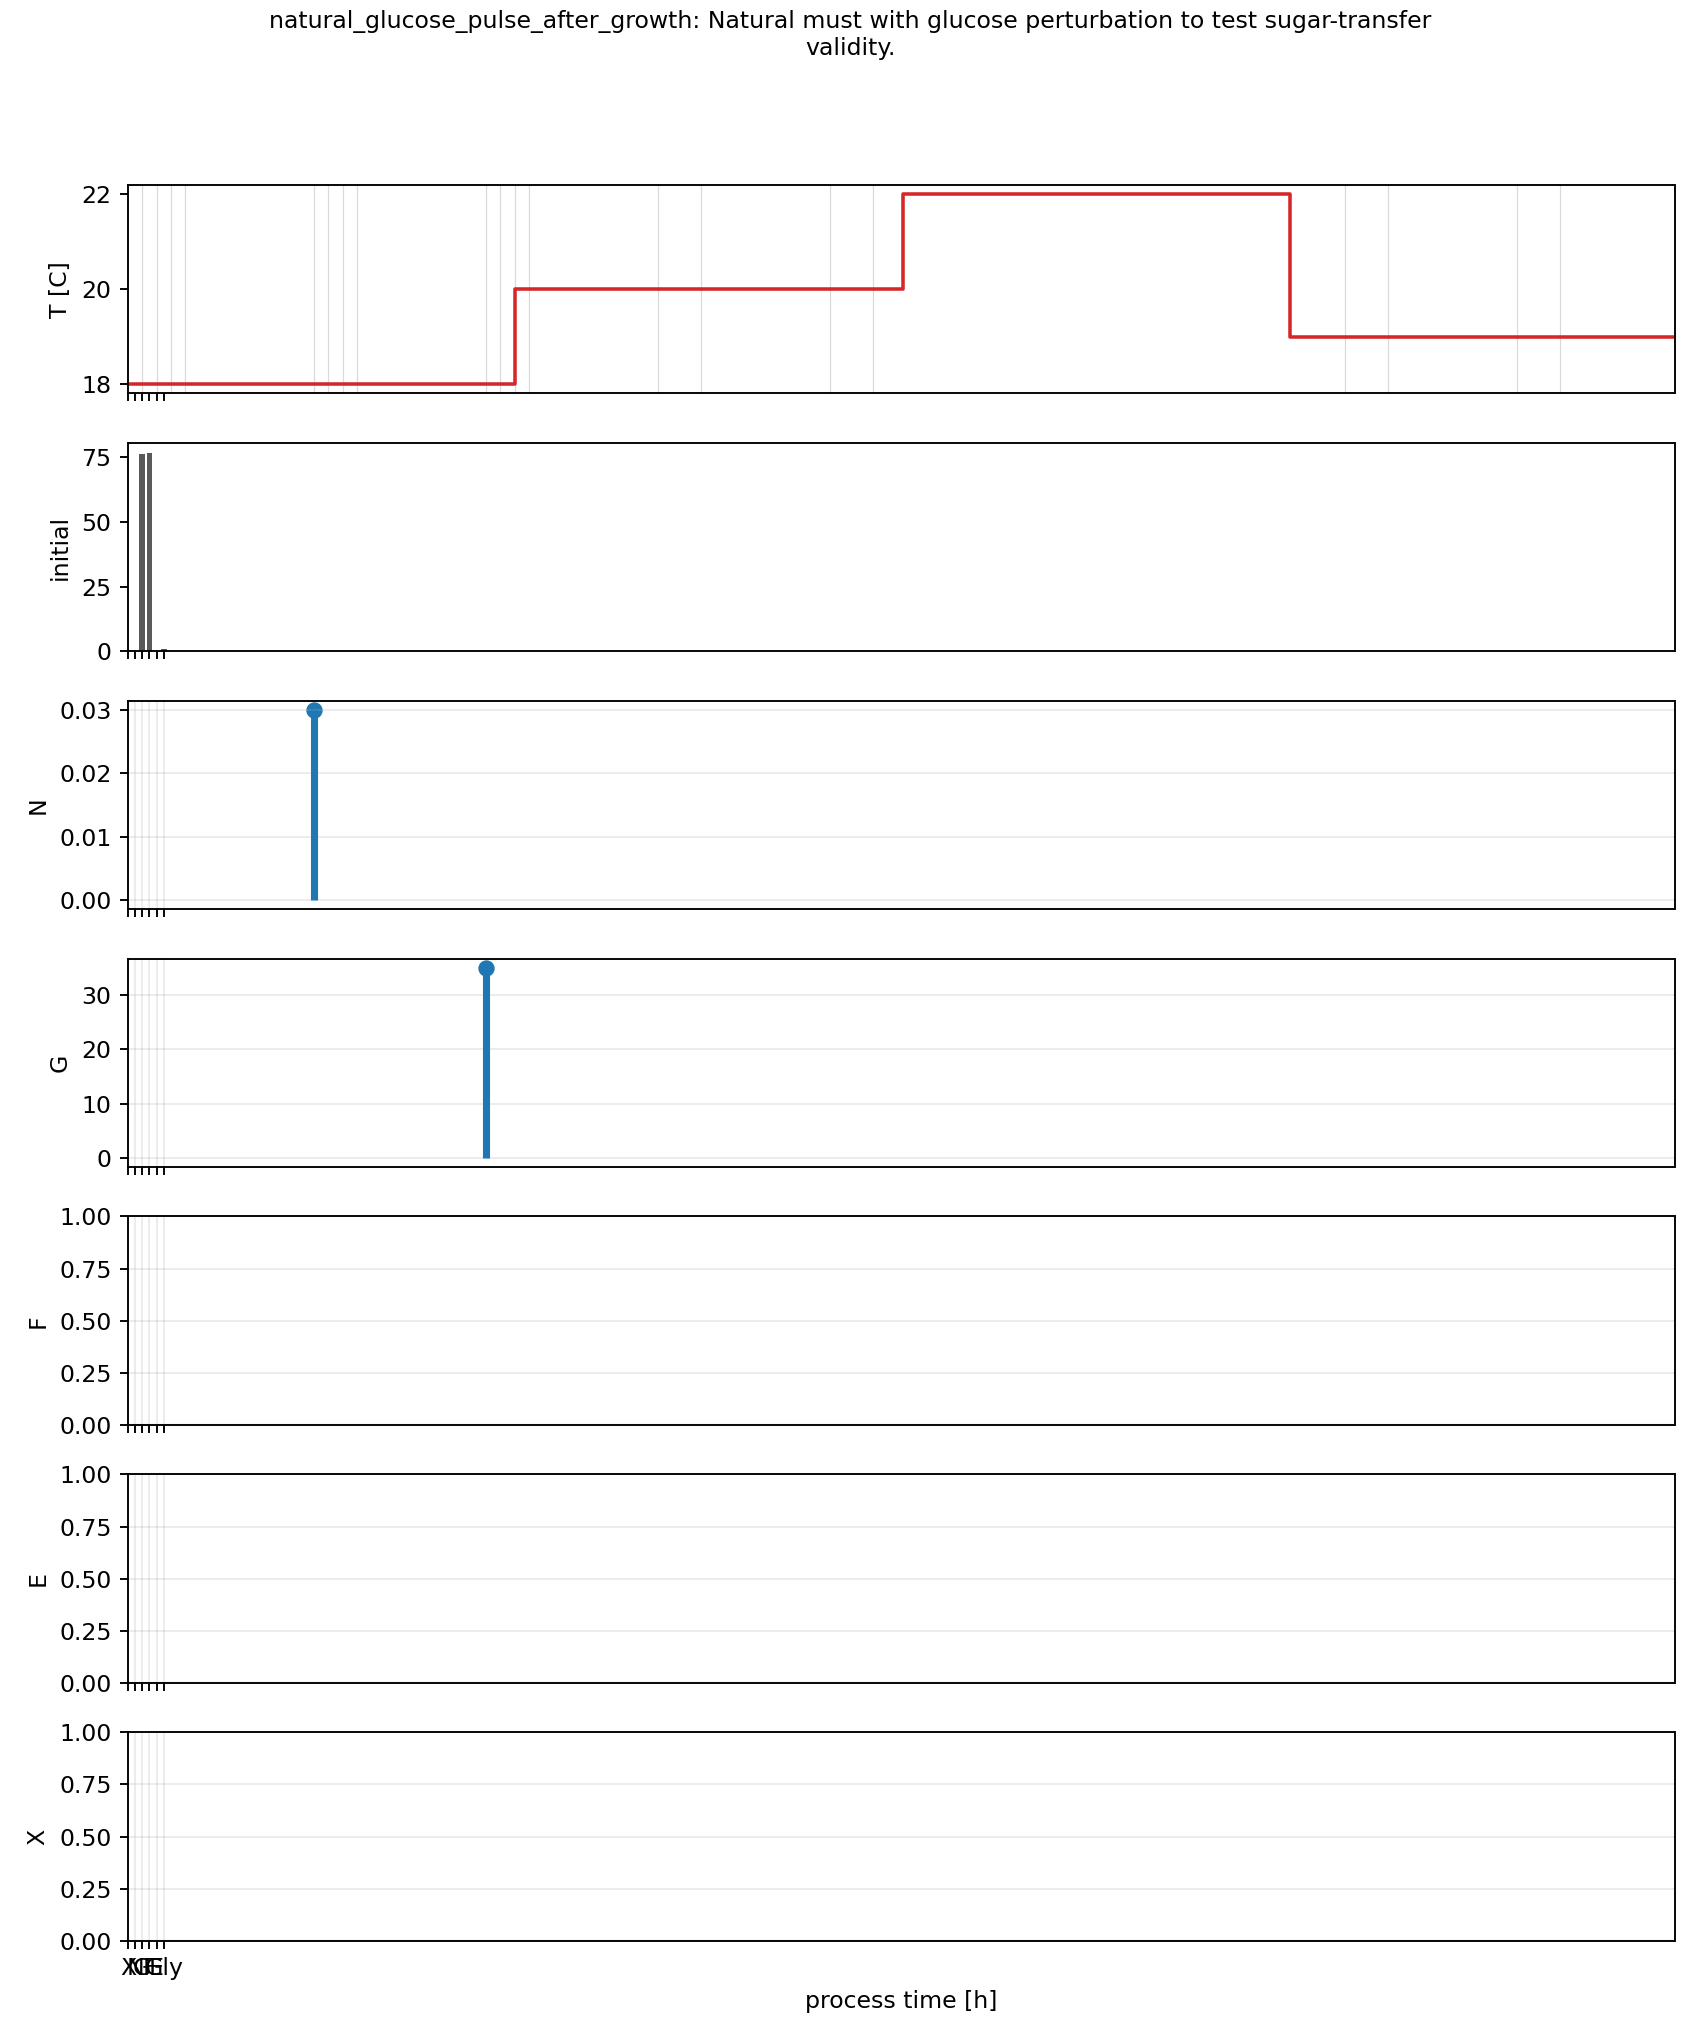

campaign_inputs_synthetic_ethanol_inhibition_challenge.png


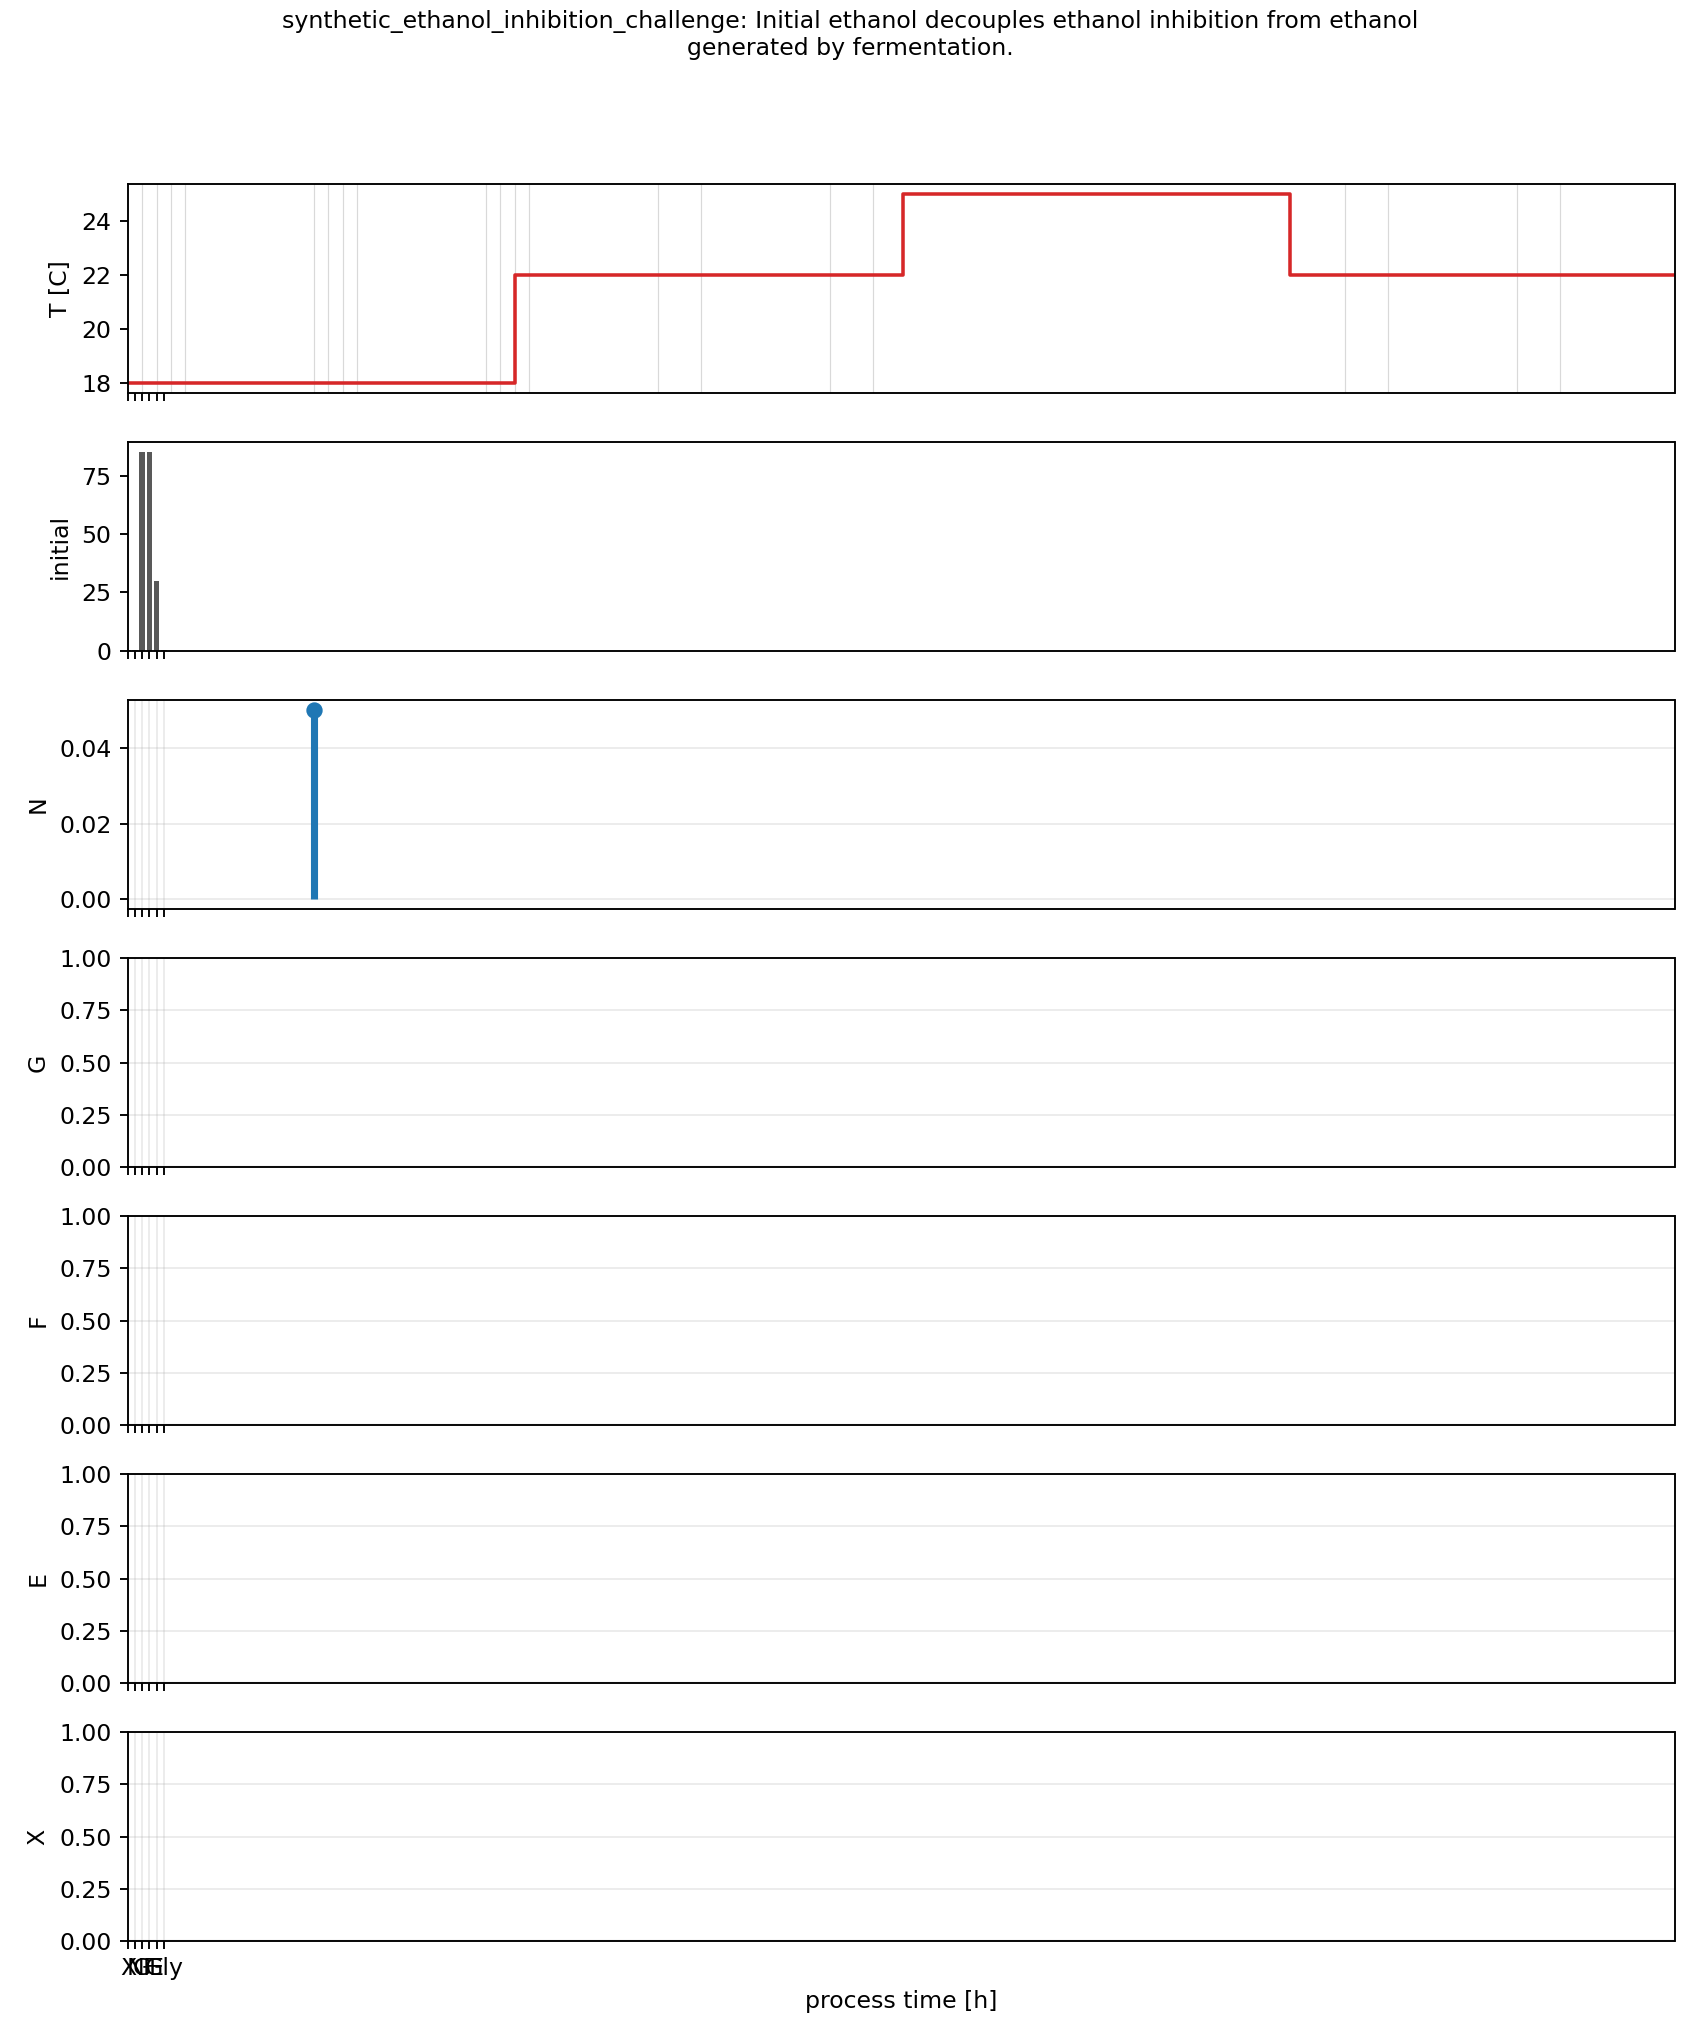

campaign_inputs_synthetic_fructose_rich_glucose_pulse.png


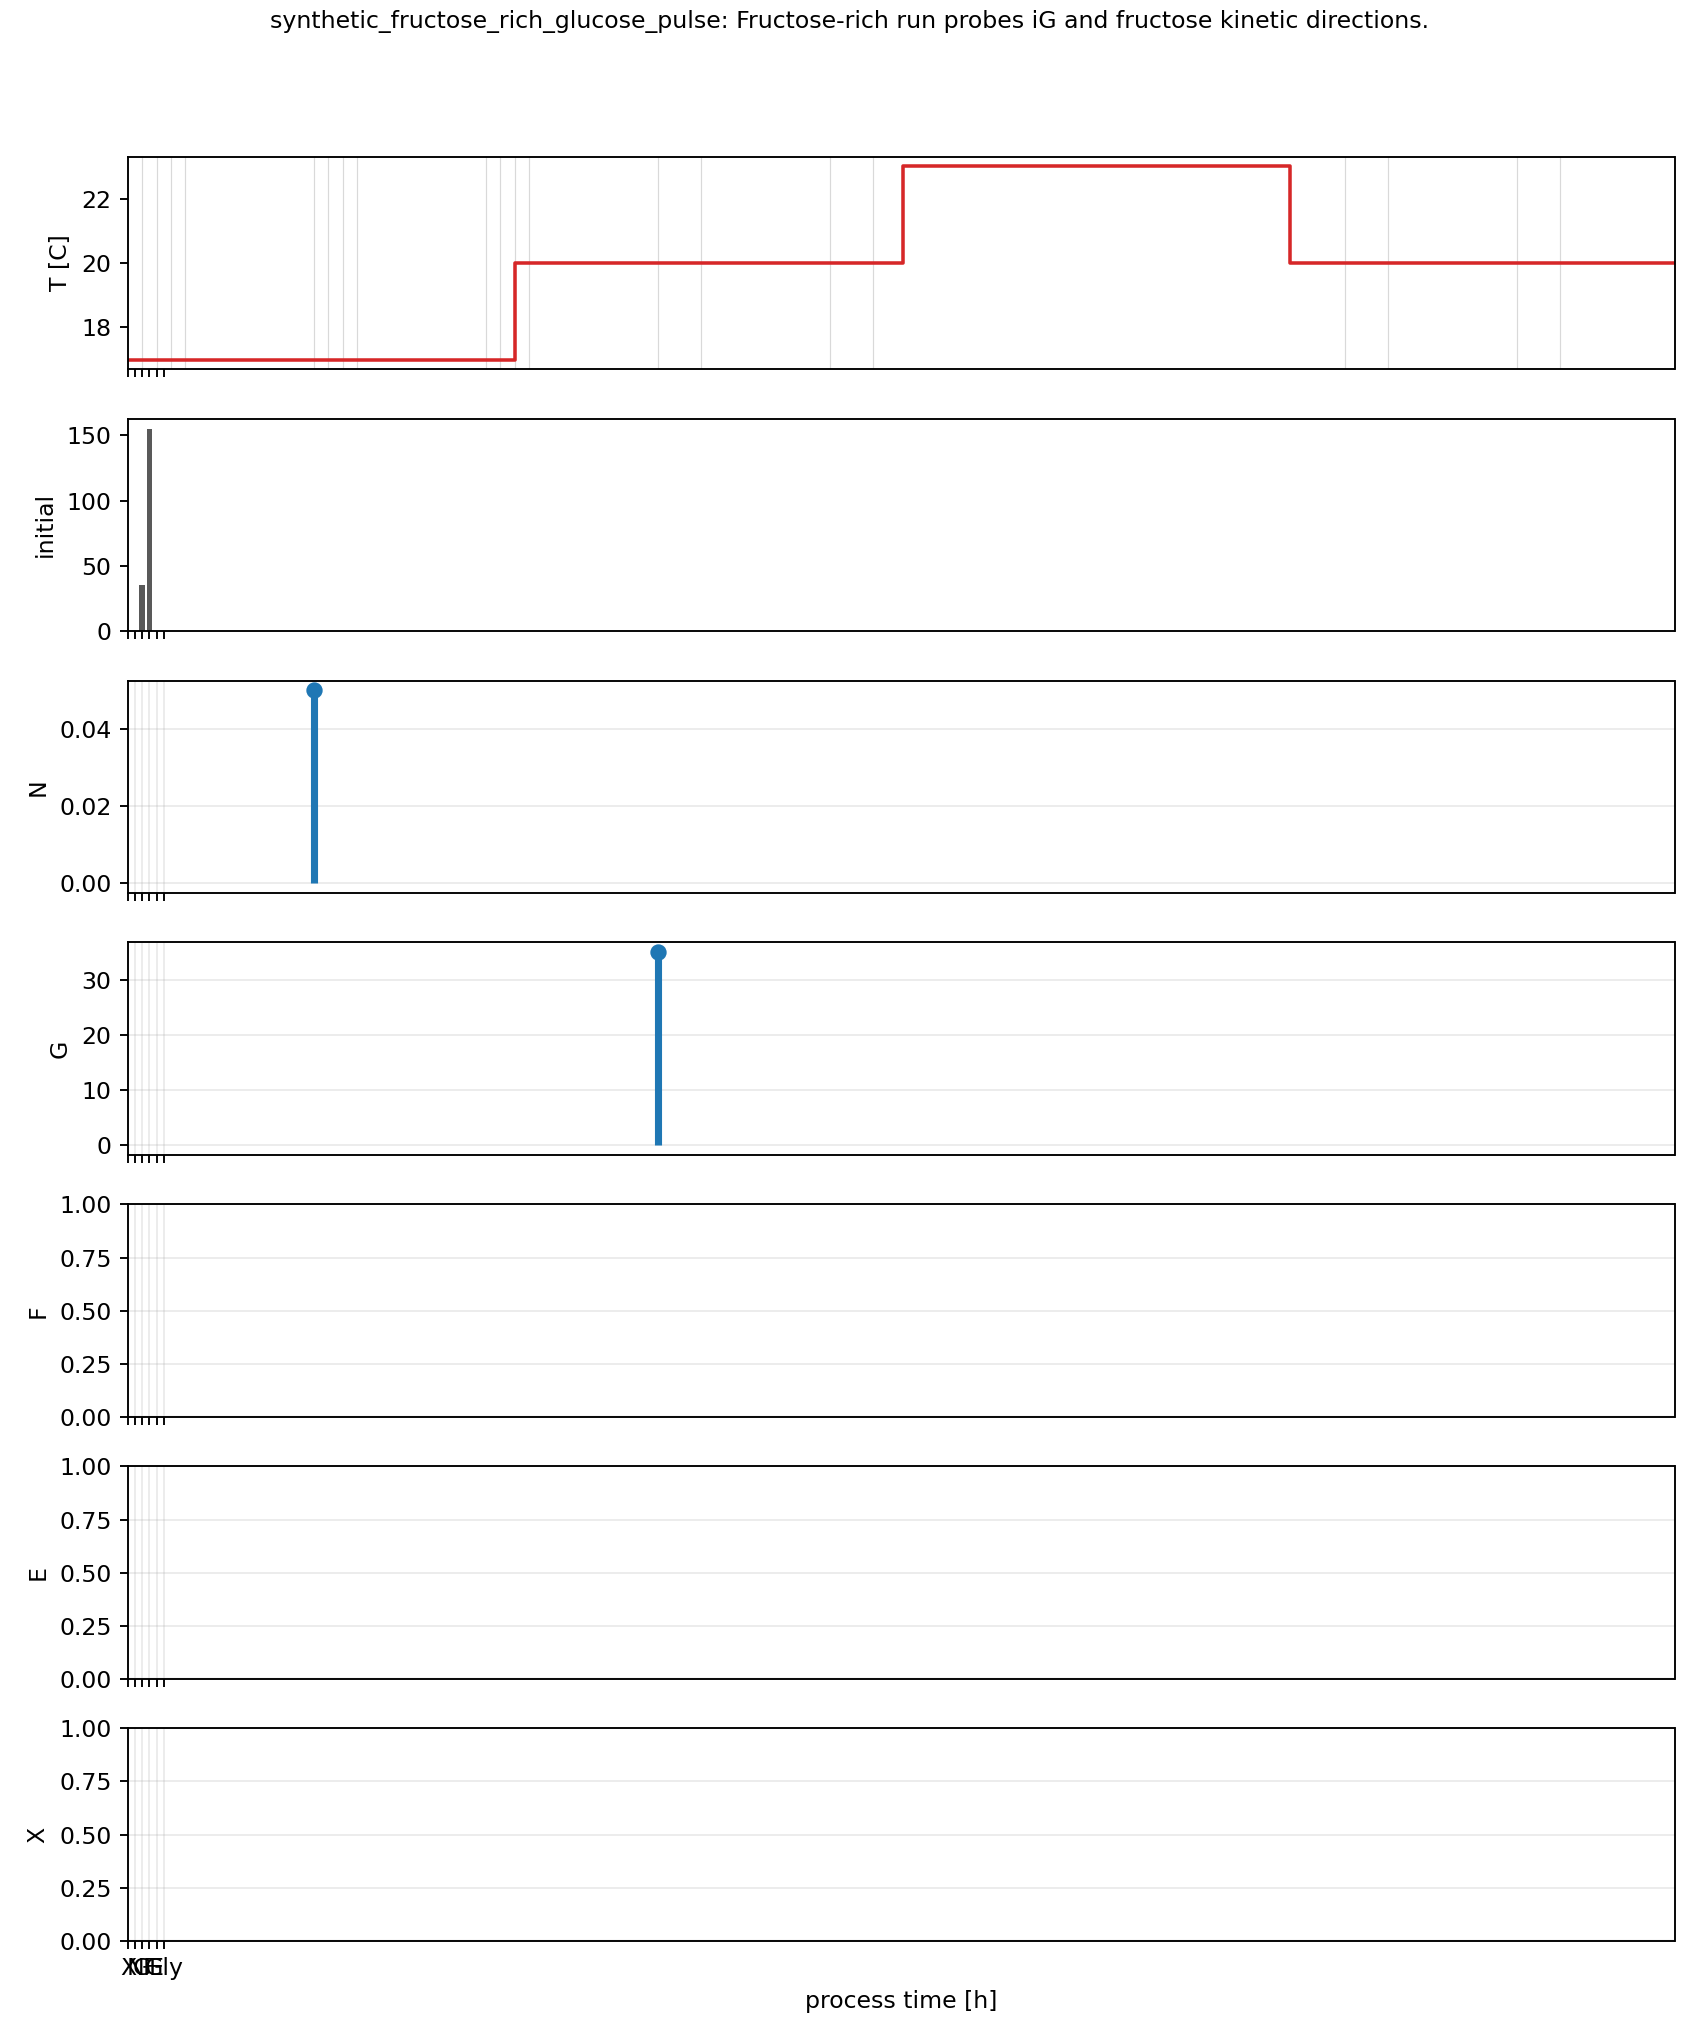

campaign_inputs_synthetic_glucose_rich_fructose_pulse.png


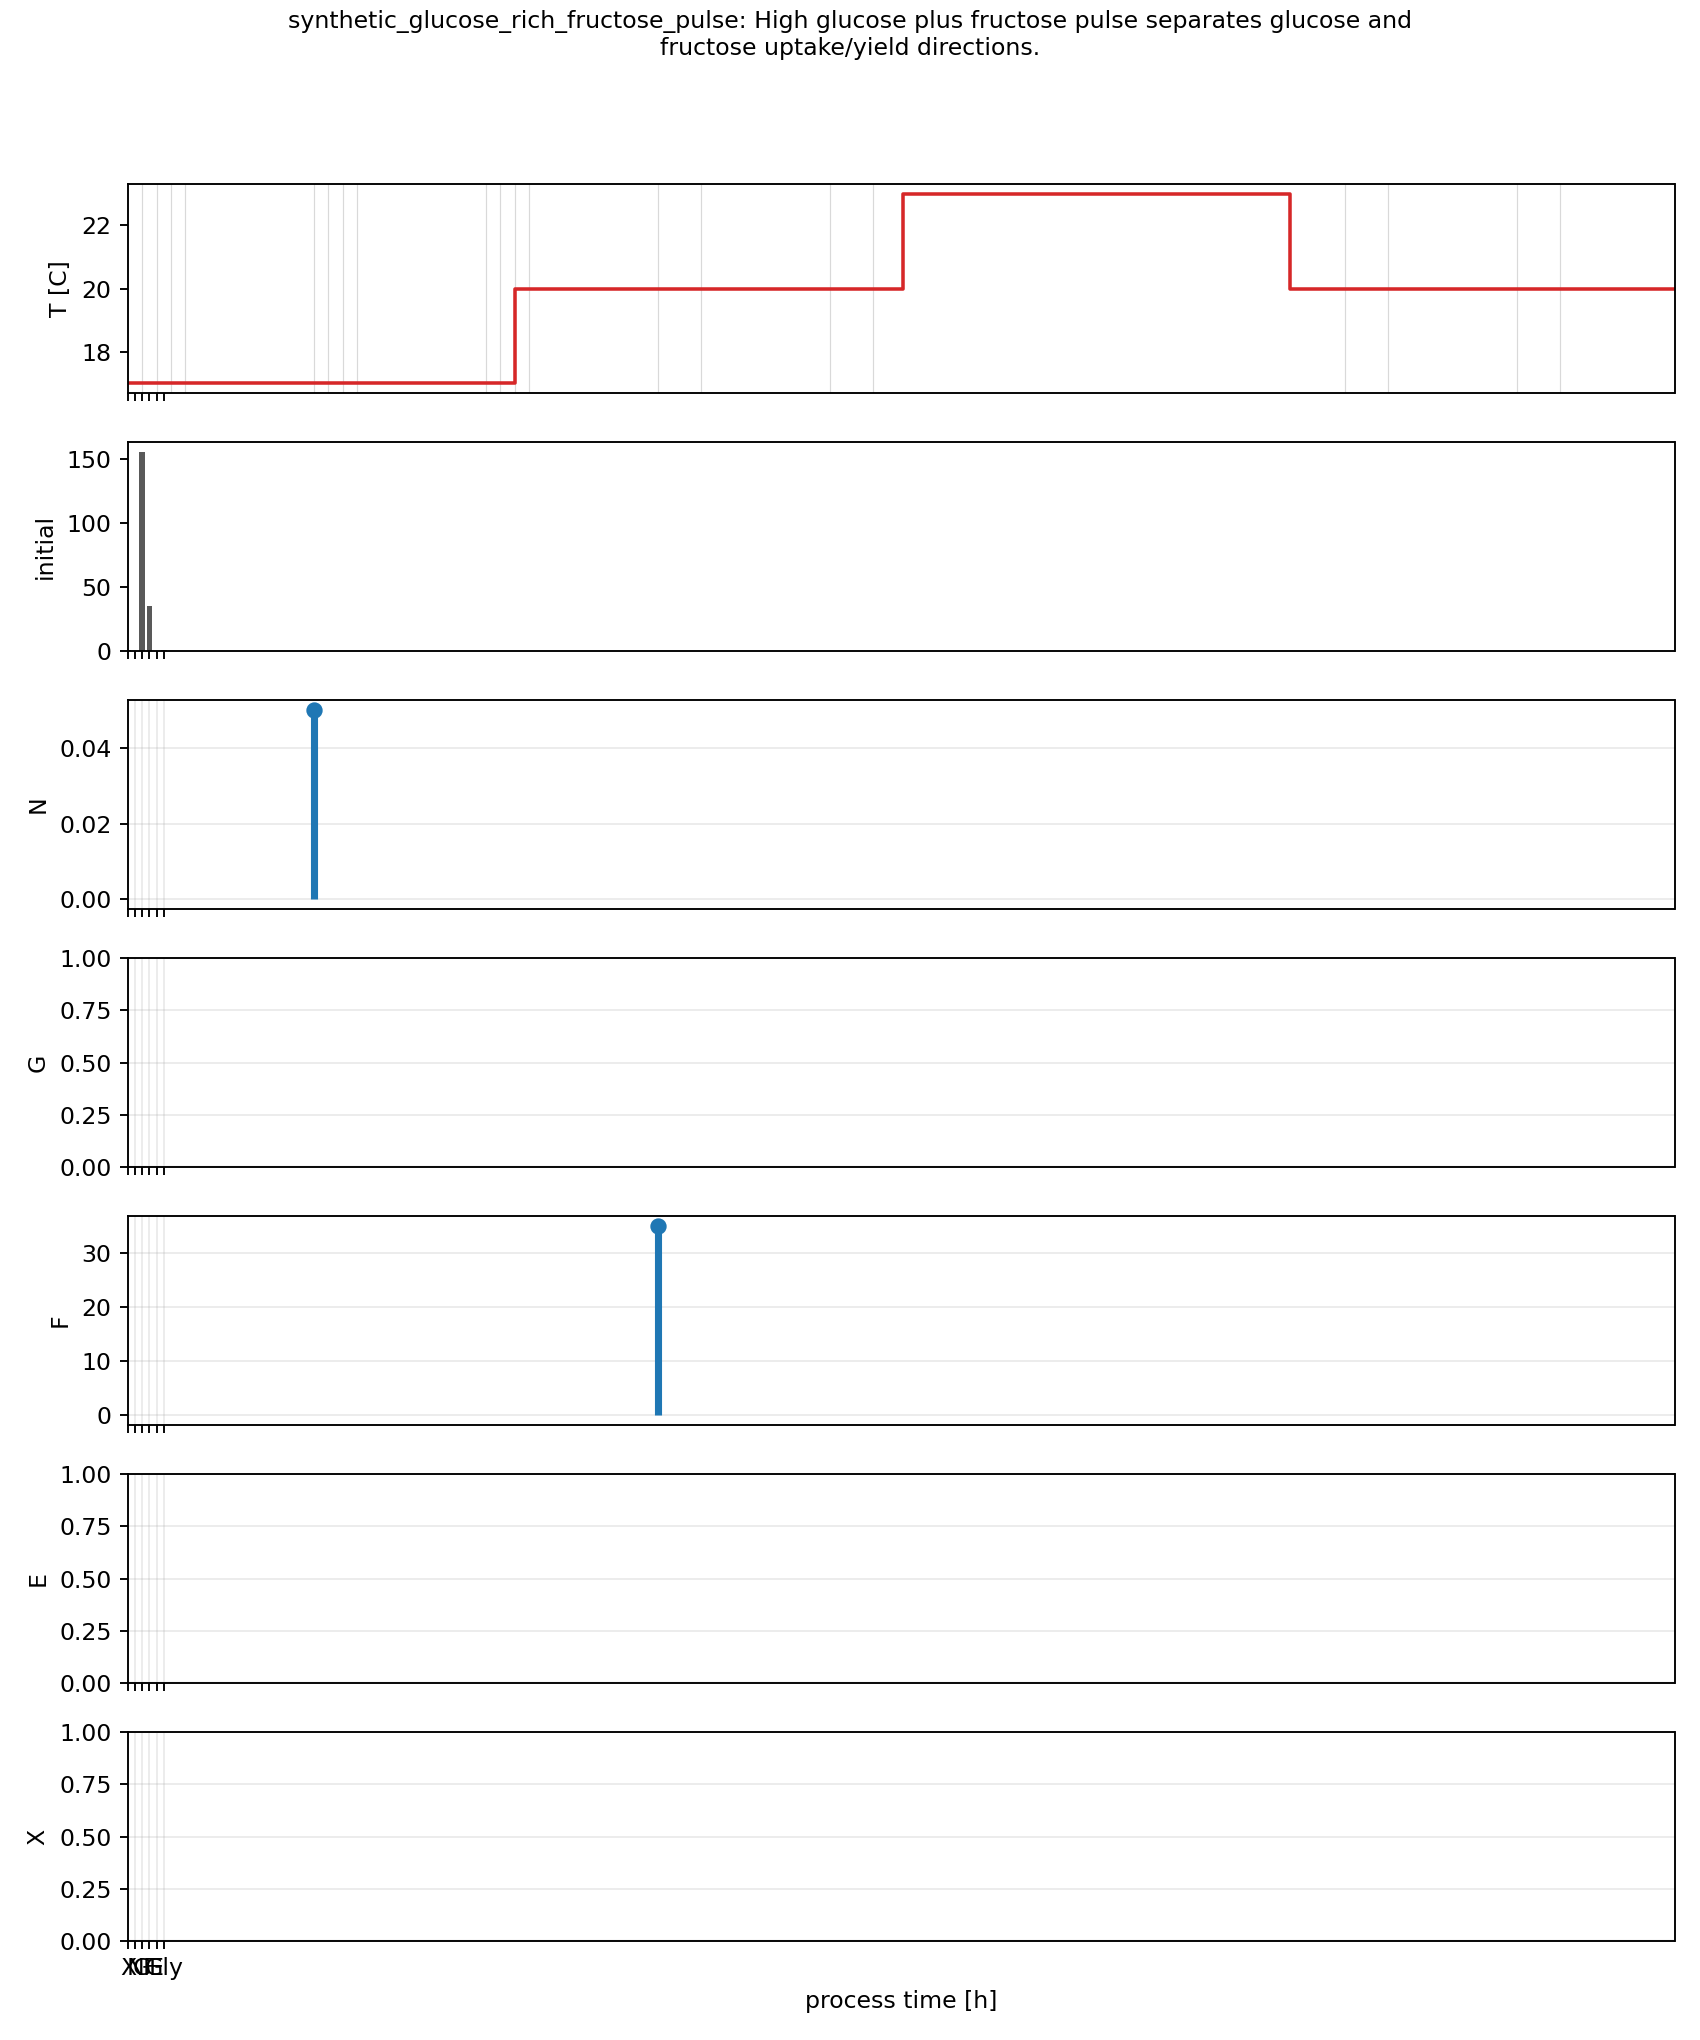

campaign_inputs_synthetic_high_biomass_low_N_maintenance.png


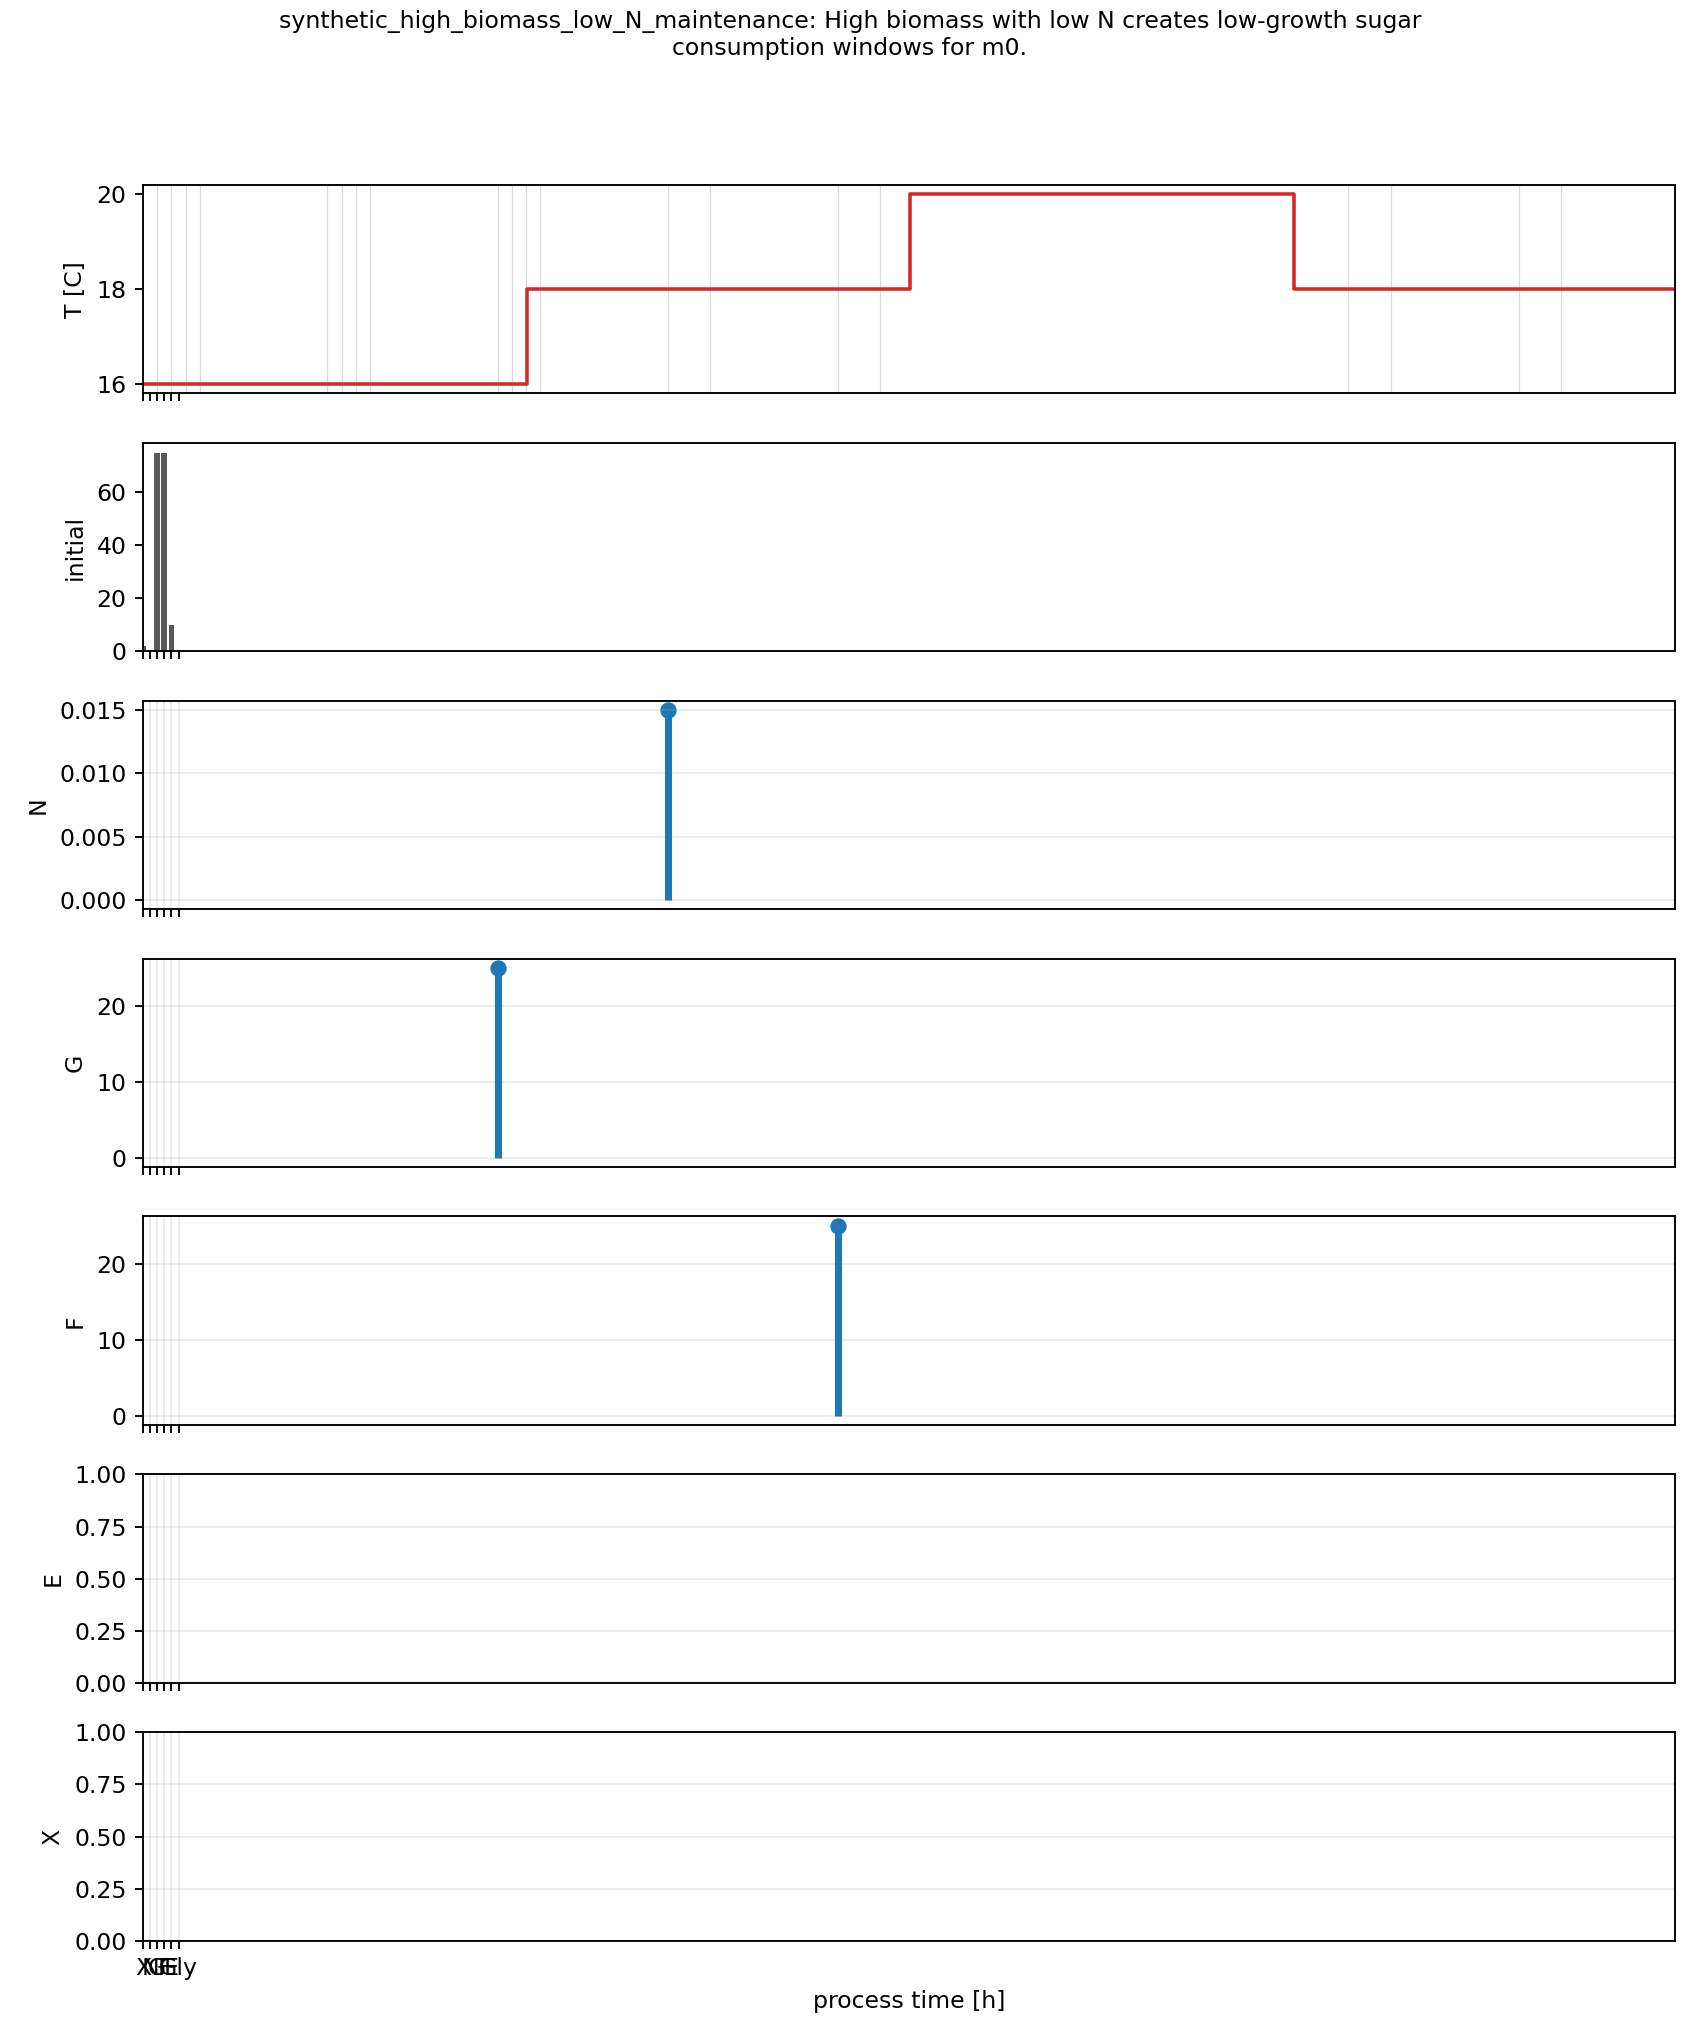

In [6]:
from IPython.display import Image, display
for png in sorted((RESULTS / 'plots').glob('campaign_inputs_*.png'))[:5]:
    print(png.name)
    display(Image(filename=str(png)))

## Pyomo.DoE usage

The runner includes a discrete Pyomo model with the same seven-state kinetics and labels `unknown_parameters`, `experiment_outputs`, and `measurement_error` for `pyomo.contrib.doe.DesignOfExperiments`. The saved `pyomo_doe_check.csv` records the sequential FIM check for the first selected experiment when Ipopt is available.

In [7]:
pyomo_path = RESULTS / 'pyomo_doe_check.csv'
pd.read_csv(pyomo_path) if pyomo_path.exists() else 'Pyomo.DoE check not available'

,candidate,status,parameters,pyomo_logdet,pyomo_min_eigenvalue,pyomo_max_eigenvalue,pyomo_min_relative_eigenvalue,pyomo_condition_number,pyomo_trace,pyomo_trace_inv,pyomo_rank_1e-8
0,synthetic_glucose_rich_fructose_pulse,ok,"mu0,qN,betaG0,betaF0,qEG,qEF,iG,iE,Kd0,gammaG0...",52.302278,0.01896,14457.323441,0.000001,762500.899378,30132.700728,54.459202,11


## How to interpret the output

Use the calibration tables to decide which parameters are already estimable from current data. Use the campaign table to decide which new fermentations most reduce weak parameter variances and improve the smallest FIM eigenvalues. After the first block of three fermentations, rerun this notebook using those data as prior information before executing the next block.